In [ ]:
# ==========================================================
# SENTRA v2
# CELL 1 : INSTALLATION & SETUP
# ==========================================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required packages
!pip install -q ultralytics
!pip install -q opencv-python-headless
!pip install -q matplotlib
!pip install -q shapely
!pip install -q scipy

# Clone YOLOv5 repository (utilities only)
!rm -rf /content/yolov5
!git clone https://github.com/ultralytics/yolov5.git

# Clone Ego Path repository
!rm -rf /content/train-ego-path-detection
!git clone https://github.com/irtrailenium/train-ego-path-detection.git

# Install Ego Path requirements
%cd /content/train-ego-path-detection
!pip install -r requirements.txt

%cd /content

import os
import cv2
import sys
import math
import torch
import random
import shutil
import subprocess
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

sys.path.append('/content/yolov5')

from yolov5.models.common import DetectMultiBackend
from yolov5.utils.general import non_max_suppression
from yolov5.utils.general import scale_boxes
from yolov5.utils.augmentations import letterbox

print("="*60)
print("SENTRA v2")
print("="*60)

print("PyTorch :", torch.__version__)
print("CUDA :", torch.cuda.is_available())

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("GPU :", torch.cuda.get_device_name(0))
else:
    DEVICE = torch.device("cpu")
    print("Running on CPU")

print("="*60)

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.6 MB/s eta 0:00:00
Cloning into 'yolov5'...
remote: Enumerating objects: 18689, done.
remote: Counting objects: 100% (285/285), done.
remote: Compressing objects: 100% (161/161), done.
remote: Total 18689 (delta 233), reused 124 (delta 124), pack-reused 18404 (from 3)
Receiving objects: 100% (18689/18689), 17.68 MiB | 9.91 MiB/s, done.
Resolving deltas: 100% (12730/12730), done.
Cloning into 'train-ego-path-detection'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 37 (delta 4), reused 4 (delta 4), pack-reused 14 (from 1)
Receiving objects: 100% (37/37), 692.45 KiB | 2.07 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/train-ego-path-detection
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 33.2 MB/s eta 

In [ ]:
# ==========================================================
# CELL 2 : EXTRACT PROJECT
# ==========================================================

import os
import zipfile
import shutil

DRIVE="/content/drive/MyDrive"

REPO=f"{DRIVE}/train-ego-path-detection.zip"
WEIGHTS=f"{DRIVE}/egopath.zip"

DEST="/content/train-ego-path-detection"

if os.path.exists(DEST):
    shutil.rmtree(DEST)

with zipfile.ZipFile(REPO,'r') as zip_ref:
    zip_ref.extractall("/content")

if os.path.exists("/content/train-ego-path-detection-main"):
    os.rename(
        "/content/train-ego-path-detection-main",
        DEST
    )

print("Repository Ready")

if os.path.exists(WEIGHTS):

    with zipfile.ZipFile(WEIGHTS,'r') as zip_ref:
        zip_ref.extractall("/content")

    print("Weights Extracted")

else:

    print("Weights ZIP not found")

Repository Ready
Weights Extracted


In [ ]:
# ==========================================================
# CELL 3 : FORCE DEVICE
# ==========================================================

import torch

DEVICE=torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device =",DEVICE)

torch.set_grad_enabled(False)

Device = cuda


torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [ ]:
# ==========================================================
# CELL 4 : LOAD YOLOv8
# ==========================================================

from ultralytics import YOLO
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("="*60)
print("Loading YOLOv8...")
print("="*60)

# Use nano model (fast on Jetson Nano)
yolo_model = YOLO("yolov8n.pt")

# Move to device
yolo_model.to(DEVICE)

print("YOLOv8 Loaded Successfully")
print("Running on:", DEVICE)

Loading YOLOv8...
YOLOv8 Loaded Successfully
Running on: cuda


In [1]:
# ==========================================================
# CELL 5 : LOAD EGO PATH DETECTOR
# ==========================================================

import os
import subprocess

class EgoPathDetector:

    def __init__(self):

        self.project="/content/train-ego-path-detection"

        self.weights=None

        weights_dir=os.path.join(
            self.project,
            "weights"
        )

        for root,dirs,files in os.walk(weights_dir):

            for f in files:

                if f.endswith(".pt"):

                    self.weights=os.path.join(root,f)

                    break

            if self.weights:
                break

        print("="*60)
        print("EGO PATH MODEL")
        print("="*60)

        print("Weights:",self.weights)

        if self.weights is None:
            raise FileNotFoundError("No EgoPath weights found!")

    def detect(self,image_path):

        output="/content/ego_output"

        if os.path.exists(output):

            import shutil
            shutil.rmtree(output)

        os.makedirs(output)

        command=[
            "python",
            os.path.join(self.project,"detect.py"),
            os.path.dirname(self.weights),
            image_path,
            "--output",
            output
        ]

        result=subprocess.run(
            command,
            cwd=self.project
        )

        images=[]

        for f in os.listdir(output):

            if f.endswith(".jpg") or f.endswith(".png"):

                images.append(
                    os.path.join(output,f)
                )

        if len(images)==0:

            return None

        images.sort()

        return images[-1]


ego_detector=EgoPathDetector()

print("Ego Path Ready")

EGO PATH MODEL
Weights: None


FileNotFoundError: No EgoPath weights found!

In [ ]:
# ==========================================================
# CELL 6 : OBSTACLE DETECTION
# ==========================================================

import cv2

INTEREST_CLASSES=[
    "person",
    "dog",
    "cat",
    "cow",
    "horse",
    "sheep",
    "bird",
    "car",
    "truck",
    "bus",
    "motorcycle",
    "bicycle"
]

def detect_obstacles(image):

    results=yolo_model.predict(

        source=image,

        imgsz=640,

        conf=0.25,

        verbose=False

    )

    detections=[]

    for r in results:

        names=r.names

        for box in r.boxes:

            cls=int(box.cls)

            name=names[cls]

            if name not in INTEREST_CLASSES:
                continue

            x1,y1,x2,y2=map(int,box.xyxy[0])

            detections.append({

                "class":name,

                "conf":float(box.conf),

                "bbox":[x1,y1,x2,y2],

                "center":(

                    (x1+x2)//2,

                    (y1+y2)//2

                )

            })

    return detections

print("Obstacle Detector Ready")

Obstacle Detector Ready


In [ ]:
# ==========================================================
# CELL 7 : CREATE RAIL MASK
# ==========================================================

import cv2
import numpy as np

def create_rail_mask(ego_image_path):

    ego=cv2.imread(ego_image_path)

    if ego is None:
        return None

    hsv=cv2.cvtColor(ego,cv2.COLOR_BGR2HSV)

    # Green rail/path mask
    lower=np.array([35,40,40])
    upper=np.array([90,255,255])

    mask=cv2.inRange(hsv,lower,upper)

    kernel=np.ones((5,5),np.uint8)

    mask=cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    mask=cv2.dilate(mask,kernel,iterations=2)

    return mask

print("Rail Mask Generator Ready")

Rail Mask Generator Ready


In [ ]:
# ==========================================================
# CELL 8 : TRACK FILTERING
# ==========================================================

def filter_track_objects(mask,detections):

    track_objects=[]

    h,w=mask.shape

    for det in detections:

        cx,cy=det["center"]

        if cx<0 or cy<0:
            continue

        if cx>=w or cy>=h:
            continue

        if mask[cy,cx]>0:

            det["on_track"]=True

            track_objects.append(det)

        else:

            det["on_track"]=False

    return track_objects

print("Track Filter Ready")

Track Filter Ready


In [ ]:
# ==========================================================
# CELL 9 : DISTANCE + RISK
# ==========================================================

import math

def estimate_distance(det):

    x1,y1,x2,y2=det["bbox"]

    width=x2-x1
    height=y2-y1

    size=max(width,height)

    if size<1:
        size=1

    # Approximate distance (meters)
    distance=250/size

    return round(distance,2)


def get_risk(distance):

    if distance<3:

        return "HIGH",(0,0,255)

    elif distance<7:

        return "MEDIUM",(0,255,255)

    else:

        return "LOW",(0,255,0)


def analyse(track_objects):

    results=[]

    for det in track_objects:

        d=estimate_distance(det)

        risk,color=get_risk(d)

        det["distance"]=d

        det["risk"]=risk

        det["color"]=color

        results.append(det)

    return results

print("Risk Module Ready")

Risk Module Ready


In [2]:
# ==========================================================
# CELL 10 : VISUALIZATION
# ==========================================================

import cv2
import numpy as np

def draw_results(image, rail_mask, results):

    output = image.copy()

    # Overlay rail mask
    green = np.zeros_like(output)
    green[:, :, 1] = rail_mask

    output = cv2.addWeighted(output, 1.0, green, 0.35, 0)

    for det in results:

        x1, y1, x2, y2 = det["bbox"]

        color = det["color"]

        cv2.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            color,
            3
        )

        text = f'{det["class"]}'

        cv2.putText(
            output,
            text,
            (x1, y1-40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            color,
            2
        )


        cv2.putText(
            output,
            det["risk"],
            (x1, y2+25),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            color,
            2
        )

        cx, cy = det["center"]

        cv2.circle(
            output,
            (cx, cy),
            5,
            (255,255,255),
            -1
        )

    return output

print("Visualization Ready")

Visualization Ready


In [ ]:
# ==========================================================
# CELL 11 : SENTRA PIPELINE
# ==========================================================

def sentra_detect(image_path):

    print("="*60)
    print("SENTRA STARTED")
    print("="*60)

    image = cv2.imread(image_path)

    if image is None:
        raise Exception("Image not found")

    # -------------------------------
    # Ego Path
    # -------------------------------
    ego_path = ego_detector.detect(image_path)

    if ego_path is None:
        raise Exception("Ego Path Failed")

    print("✓ Ego Path Complete")

    # -------------------------------
    # Rail Mask
    # -------------------------------
    rail_mask = create_rail_mask(ego_path)

    print("✓ Rail Mask Generated")

    # -------------------------------
    # YOLO Detection
    # -------------------------------
    detections = detect_obstacles(image)

    print(f"✓ Total Detections : {len(detections)}")

    # -------------------------------
    # Keep only track objects
    # -------------------------------
    track_objects = filter_track_objects(
        rail_mask,
        detections
    )

    print(f"✓ Objects On Track : {len(track_objects)}")

    # -------------------------------
    # Risk
    # -------------------------------
    results = analyse(track_objects)

    # -------------------------------
    # Draw
    # -------------------------------
    output = draw_results(
        image,
        rail_mask,
        results
    )

    return output

Saving Human-Obstacle-31-_jpg.rf.1ae1c9306edcfb063811b4f417074c4e.jpg to Human-Obstacle-31-_jpg.rf.1ae1c9306edcfb063811b4f417074c4e.jpg
SENTRA STARTED
✓ Ego Path Complete
✓ Rail Mask Generated
✓ Total Detections : 2
✓ Objects On Track : 1


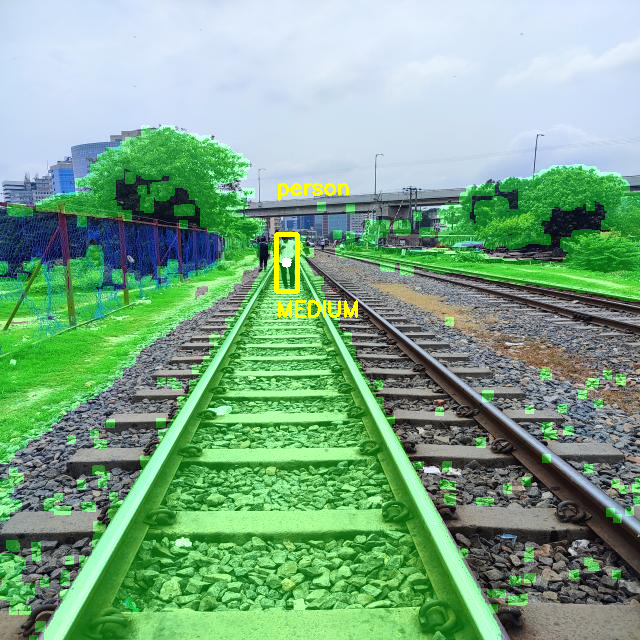


Result Saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================================
# CELL 12 : RUN SENTRA
# ==========================================================

from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

if len(uploaded):

    image_name = list(uploaded.keys())[0]

    result = sentra_detect(
        "/content/" + image_name
    )

    cv2_imshow(result)

    save_path = "/content/SENTRA_Result.jpg"

    cv2.imwrite(
        save_path,
        result
    )

    print()

    print("Result Saved")

    files.download(save_path)

else:

    print("No Image Uploaded")

In [ ]:
!find /content -name best.pt

/content/drive/MyDrive/SENTRA/best.pt
/content/train-ego-path-detection/weights/twinkling-rocket-21/best.pt
/content/train-ego-path-detection/weights/chromatic-laughter-5/best.pt
/content/train-ego-path-detection/weights/fortuitous-pig-8/best.pt
/content/train-ego-path-detection/weights/brilliant-horse-15/best.pt
/content/train-ego-path-detection/weights/fortuitous-goat-12/best.pt
/content/train-ego-path-detection/weights/logical-tree-1/best.pt


In [ ]:
import ultralytics
print(ultralytics.__version__)